<a href="https://colab.research.google.com/github/beecall17/Fuse-AI-Fellowship/blob/main/Image%20Processing%20%5BWeek%2010%5D/Image_Processing_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part A — Color Space & Fruit Segmentation


In [69]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow


In [70]:
print(f"Open cv version:", cv2.__version__)
print(f"Numpy version:",np.__version__)

Open cv version: 4.13.0
Numpy version: 2.0.2


In [71]:
# Image plot Helper function --
def plot_images(images, titles=None, figsize=None, cmap='gray'):
    """
    Plots a list of images side by side.

    Args:
        images (list): A list of 2D orimages.
        titles (list, optional): A list of str 3D numpy arrays representing ings for subplot titles.
                                 Defaults to None.
        figsize (tuple, optional): Figure size (width, height) in inches.
                                   If None, it's calculated automatically.
                                   Defaults to None.
        cmap (str, optional): Colormap for displaying images. Defaults to 'gray'.
                              Set to None for Matplotlib to infer for RGB/RGBA images.

    Returns:
        tuple: (matplotlib.figure.Figure, matplotlib.axes.Axes or list of Axes)
               The figure and axes objects of the plot.
    """
    num_images = len(images)

    if figsize is None:
        # Dynamically adjust figure size based on the number of images
        # Assuming each image takes roughly 5x5 inches for a good display
        figsize = (num_images * 5, 5) # Width is num_images * 5, height is 5

    fig, ax = plt.subplots(1, num_images, figsize=figsize)

    # Ensure ax is always iterable, even for a single image
    if num_images == 1:
        ax = [ax]

    for i in range(num_images):
        ax[i].imshow(images[i], cmap=cmap)
        if titles is not None and i < len(titles):
            ax[i].set_title(titles[i])
        ax[i].axis('off')

    plt.tight_layout()
    plt.show()



1. Load red_apple.jpg in BGR using cv2.imread(). Display
it correctly in Matplotlib (convert to RGB first). Then display the raw BGR
version. What do you notice about the colors?

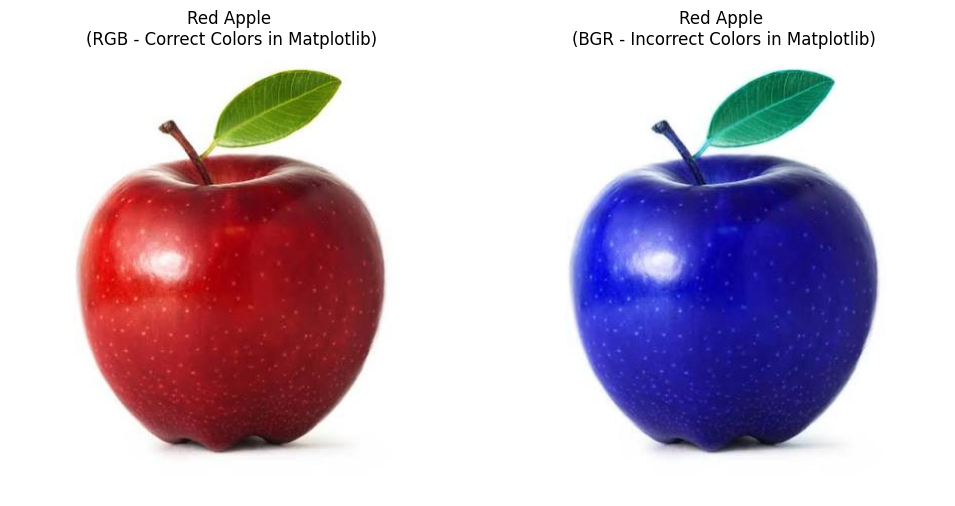

In [72]:
# Image loaded
red_apple_img = cv2.imread("/content/drive/MyDrive/Fuse AI Fellowship/Image Processing/red_apple.jpg")
# BGR TO RBG
red_apple_rgb = cv2.cvtColor(red_apple_img, cv2.COLOR_BGR2RGB)

plot_images(images=[red_apple_rgb, red_apple_img],
            titles=["Red Apple \n(RGB - Correct Colors in Matplotlib)",
                    "Red Apple \n(BGR - Incorrect Colors in Matplotlib)"])

* OpenCV uses BGR format, so without converting to RGB first, the blue and red colors are swapped
* After applying BGR2RBG, the matplotlib correctly displays the original image.

In [73]:
print(f"red_apple_img.shape: {red_apple_img.shape}")
print(f"red_apple_img.dtype: {red_apple_img.dtype}")

red_apple_img.shape: (447, 447, 3)
red_apple_img.dtype: uint8


* The red apple image is of 447,447 height and width with 3 color channels.

2. Convert red_apple.jpg to HSV. Visualize the H, S, and V
channels side by side as grayscale images.

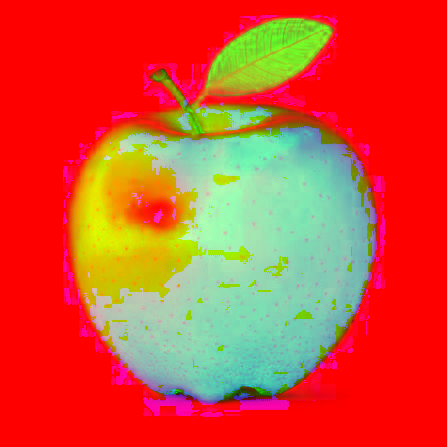

In [74]:
red_apple_hsv = cv2.cvtColor(red_apple_img, cv2.COLOR_BGR2HSV)
cv2_imshow(red_apple_hsv)

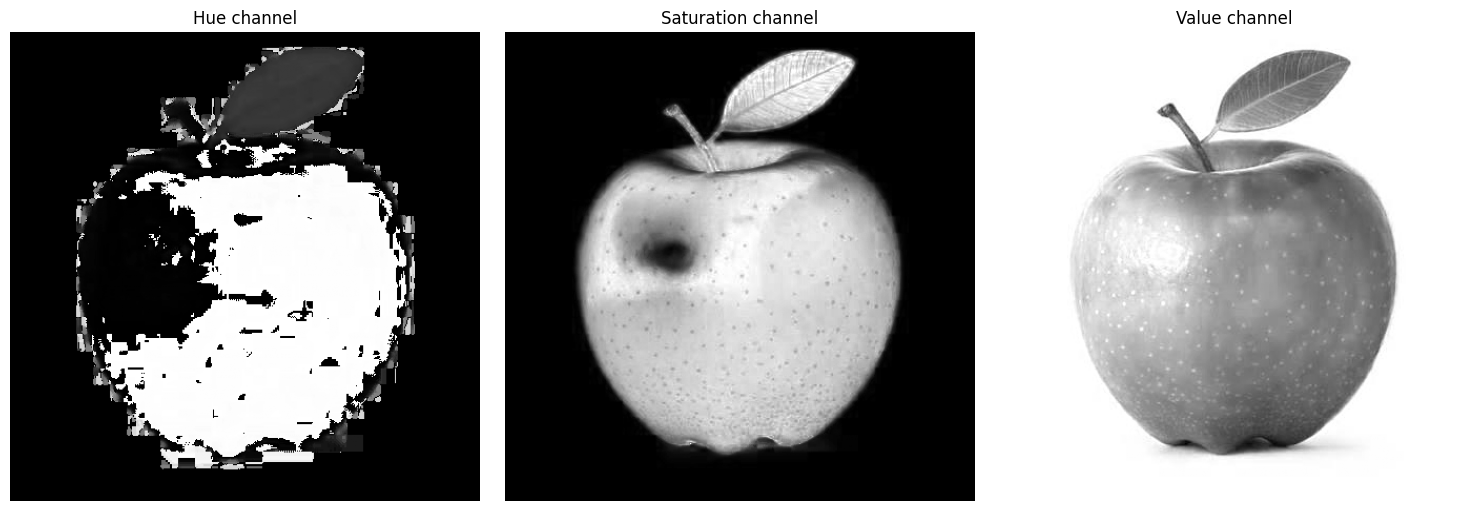

In [75]:
# Splitting h, s, v from red apple converted to hsv
h, s, v = cv2.split(red_apple_hsv)

# Visualize the h, s, v split images
plot_images(images=[h,s,v],
            titles=["Hue channel", "Saturation channel", "Value channel"])

Which channel best separates the
fruit from its white background?
> **Hue** - shows the color but the figure itself is not that clear on seperation with background.
>
> **Saturation** - the eges are seperated well from the background. The area where the light was shiny (from original), shows the deep like a rotten piece but in actual it might be deu to lighting.
>
> **Value** - the image is well seperated from white background, the image / freshness of fruit can be seen clearly as well. `V channel` is the most well seperated among all.

**Color table task:**

| Fruit       | H_min | H_max | S_min | S_max | V_min | V_max |
|:------------|:------|:------|:------|:------|:------|:------|
| `red_apple.jpg` (Lower) | 0     | 10    | 70    | 255   | 70    | 255   |
| `red_apple.jpg` (Upper) | 170   | 180   | 70    | 255   | 70    | 255   |
| `green_apple.jpg` | 35    | 85    | 50    | 255   | 50    | 255   |
| `banana.jpg`    | 20    | 35    | 50    | 255   | 50    | 255   |
| `lime.jpg`      | 25    | 60    | 50    | 255   | 50    | 255   |


3. Masking by color: use cv2.inRange() in HSV to isolate
the red apple. Red wraps around the Hue axis (0–10 and 170–180). Create two
masks and combine with cv2.bitwise_or(). Display: original | mask | masked
result.

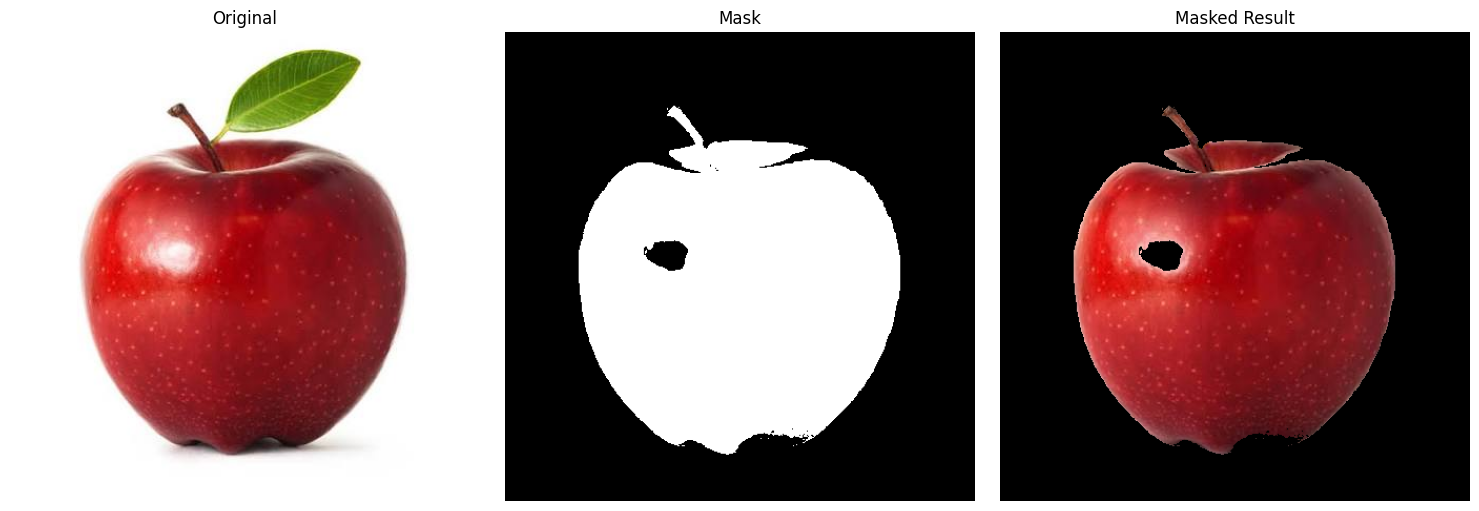

In [77]:
# HSV Masking for red apple

# Lower mask
mask1_lower_red = np.array([0,70,70])
mask1_upper_red = np.array([10,255,255])
mask1 = cv2.inRange(red_apple_hsv, mask1_lower_red, mask1_upper_red)

mask2_lower_red = np.array([170,70,70])
mask2_upper_red = np.array([180,255,255])
mask2 = cv2.inRange(red_apple_hsv, mask2_lower_red, mask2_upper_red)

mask = cv2.bitwise_or(mask1, mask2)

result_mask_red_apple = cv2.bitwise_and(red_apple_rgb, red_apple_rgb, mask=mask)

plot_images(images=[red_apple_rgb, mask, result_mask_red_apple],
            titles=["Original", "Mask", "Masked Result"])

4. Repeat the HSV masking for
green_apple.jpg, banana.jpg, and lime.jpg.


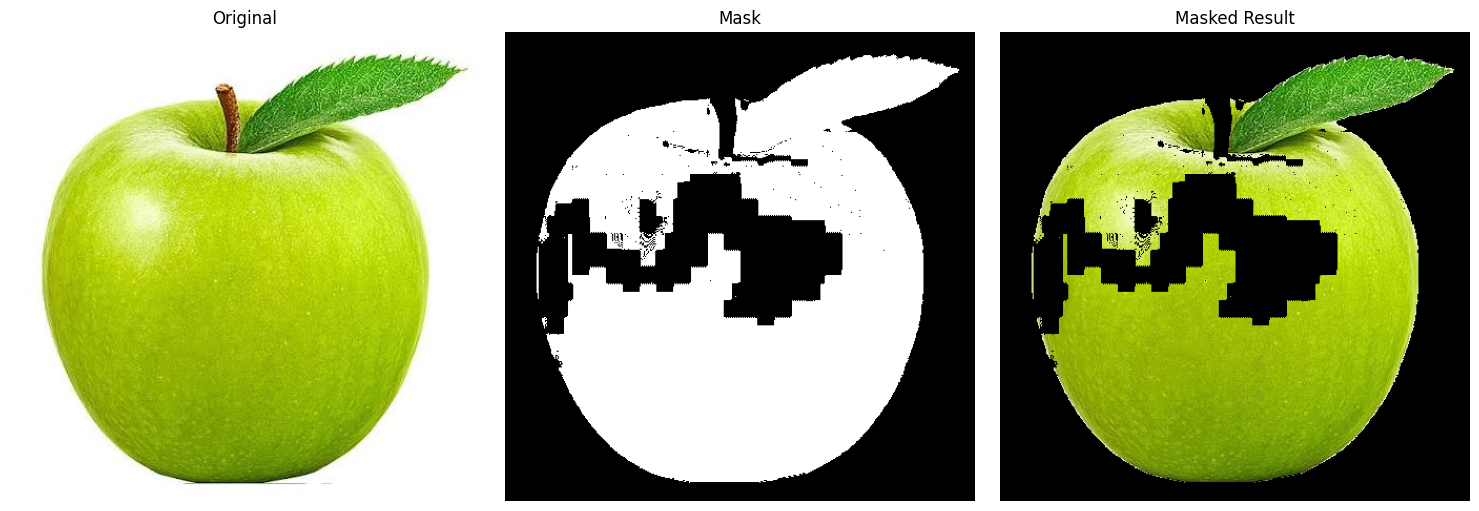

In [80]:
green_apple = cv2.imread('/content/drive/MyDrive/Fuse AI Fellowship/Image Processing/green_apple.jpg')

green_apple_rgb = cv2.cvtColor(green_apple, cv2.COLOR_BGR2RGB)
green_apple_hsv = cv2.cvtColor(green_apple_rgb, cv2.COLOR_RGB2HSV)

# HSV Masking for green apple
upper_green = np.array([85,255,255])
lower_green = np.array([35,50,50])

mask_green = cv2.inRange(green_apple_hsv, lower_green, upper_green)

result_mask_green_apple = cv2.bitwise_and(green_apple_rgb, green_apple_rgb, mask=mask_green)

plot_images(images=[green_apple_rgb, mask_green, result_mask_green_apple],
            titles=["Original", "Mask", "Masked Result"])

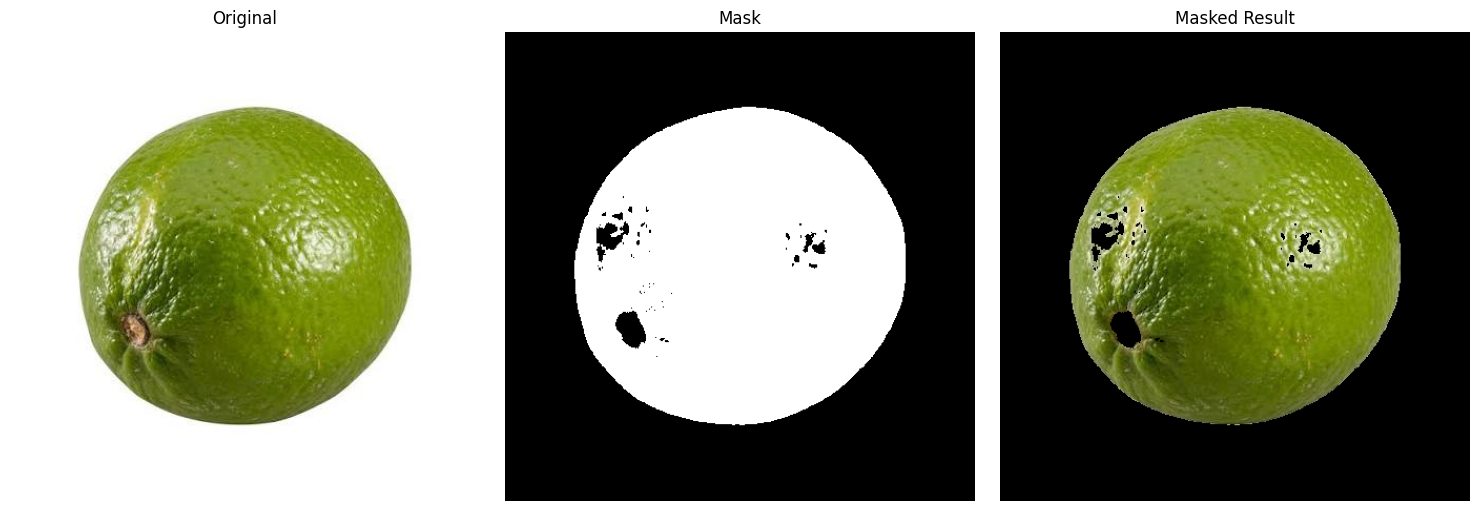

In [82]:
lime = cv2.imread('/content/drive/MyDrive/Fuse AI Fellowship/Image Processing/lime.jpg')

lime_rgb = cv2.cvtColor(lime, cv2.COLOR_BGR2RGB)
lime_hsv = cv2.cvtColor(lime_rgb, cv2.COLOR_RGB2HSV)

lower_lime = np.array([25,50,50])
upper_lime = np.array([60,255,255])

mask_lime = cv2.inRange(lime_hsv, lower_lime, upper_lime)

result_mask_lime = cv2.bitwise_and(lime_rgb, lime_rgb, mask=mask_lime)

plot_images(images=[lime_rgb, mask_lime, result_mask_lime],
            titles=["Original", "Mask", "Masked Result"])

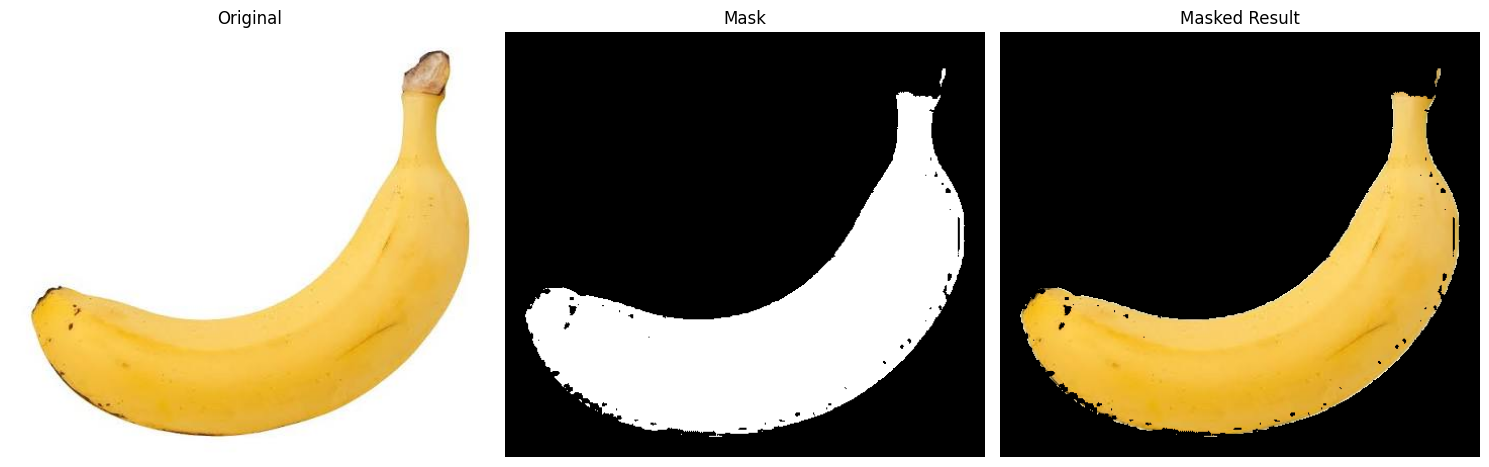

In [81]:
banana = cv2.imread('/content/drive/MyDrive/Fuse AI Fellowship/Image Processing/banana.jpg')

banana_rgb = cv2.cvtColor(banana, cv2.COLOR_BGR2RGB)
banana_hsv = cv2.cvtColor(banana_rgb, cv2.COLOR_RGB2HSV)

# HSV Masking for banana
upper_banana = np.array([35,255,255])
lower_banana = np.array([20,50,50])

mask_banana = cv2.inRange(banana_hsv, lower_banana, upper_banana)

result_mask_banana = cv2.bitwise_and(banana_rgb, banana_rgb, mask=mask_banana)

plot_images(images=[banana_rgb, mask_banana, result_mask_banana],
            titles=["Original", "Mask", "Masked Result"])


5. Apply manual brightness/contrast to a dark banana image
(alpha=1.3, beta=20) using NumPy. Clip to [0,255] and convert to uint8. Compare
to cv2.convertScaleAbs()

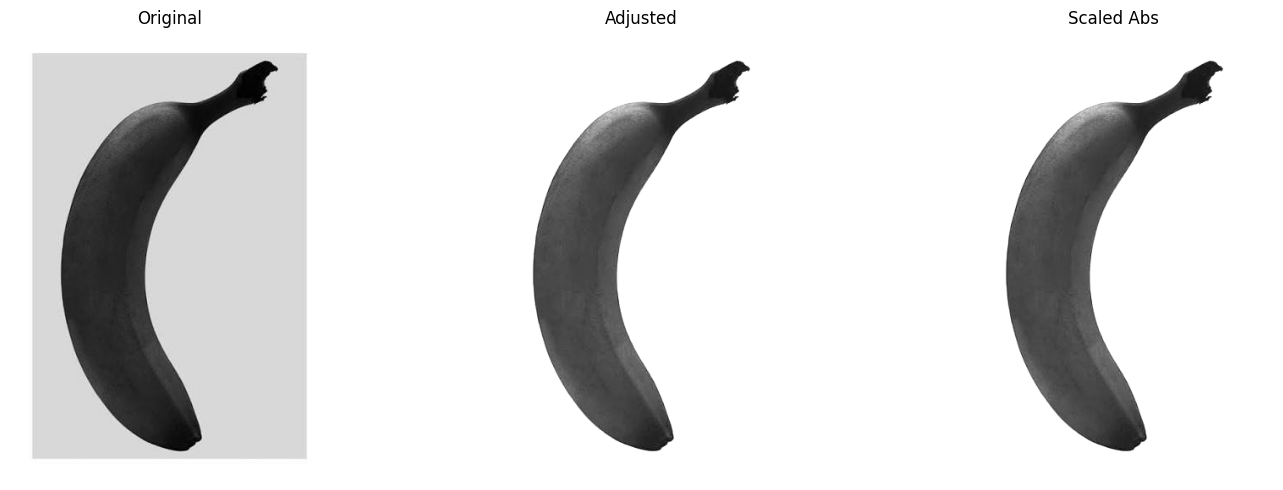

In [90]:
def adjust_brightness_contrast(img, alpha=1.3, beta=20):
    img_float = img.astype(np.float32)
    img_float = img_float * alpha + beta
    img_float = np.clip(img_float, 0, 255)
    return img_float.astype(np.uint8)

dark_banana = cv2.imread('/content/drive/MyDrive/Fuse AI Fellowship/Image Processing/dark_banana.png')
dark_banana_rgb = cv2.cvtColor(dark_banana, cv2.COLOR_BGR2RGB)
banana_adjusted = adjust_brightness_contrast(dark_banana_rgb, alpha=1.3, beta=20)
banana_adjusted_abs = cv2.convertScaleAbs(dark_banana_rgb, alpha=1.3, beta=20)
plot_images(images=[dark_banana_rgb, banana_adjusted, banana_adjusted_abs ],
            titles=["Original", "Adjusted", "Scaled Abs"])

* Manual converting brightness/contrast is resulted same as using built in funciton of convertscaledabs.

* The dark image (banana) lights up and its not completely dark after the adjustment.

6.  Reflection: why does HSV work better than RGB for fruit
color segmentation? When would it fail? (Hint: try a very dark purple grape or
blueberry.)

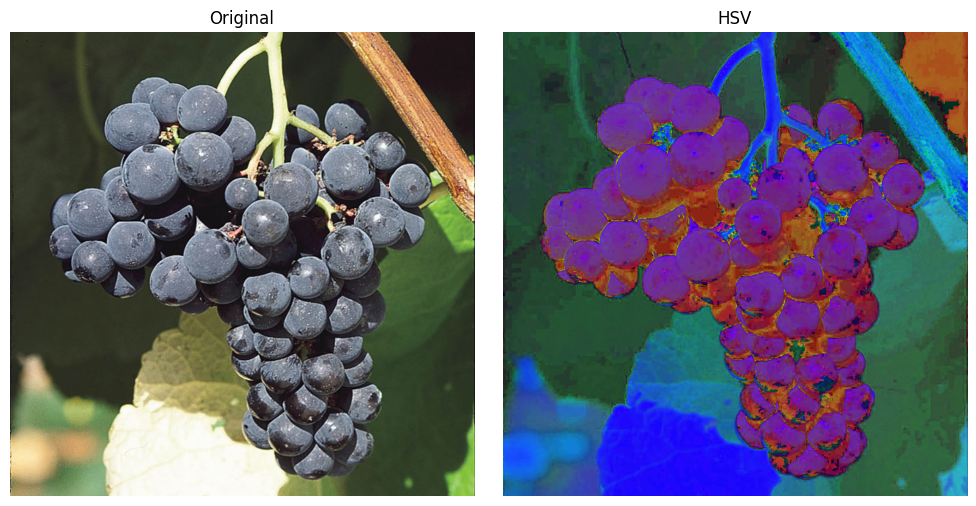

In [97]:
dark_purple_grape = cv2.imread('/content/drive/MyDrive/Fuse AI Fellowship/Image Processing/dark_purple_grape.png')
dark_purple_grape_rgb = cv2.cvtColor(dark_purple_grape, cv2.COLOR_BGR2RGB)
dark_purple_grape_hsv = cv2.cvtColor(dark_purple_grape_rgb, cv2.COLOR_RGB2HSV)

plot_images(images=[dark_purple_grape_rgb,dark_purple_grape_hsv],
            titles=["Original", "HSV"])

### Reflection: Why HSV for Color Segmentation?

1.  **Intuitive Color Representation:** HSV separates color information (Hue and Saturation) from intensity information (Value/Brightness). In contrast, RGB combines these aspects, meaning that a change in brightness will alter all three R, G, and B components. This makes defining color ranges in RGB much harder and less robust to lighting variations.

2.  **Robustness to Lighting:** Because Hue and Saturation are less affected by changes in light intensity than RGB components, HSV makes it easier to segment objects based purely on their color, even under different lighting conditions. For example, a red apple will generally have a consistent Hue value regardless of whether it's brightly lit or slightly shadowed, whereas its R, G, and B values would change significantly.

3.  **Simplified Thresholding:** In HSV, you can define a narrow range for Hue to target a specific color (e.g., green for green apples, yellow for bananas). Saturation helps to filter out gray or desaturated areas (like white backgrounds), and Value can help to include or exclude very dark/bright regions. This often leads to cleaner masks with simpler thresholding logic compared to complex multi-dimensional thresholding required in RGB.

### When HSV Segmentation Can Fail (e.g., Dark Purple Grape):

While powerful, HSV is not foolproof. It can struggle in certain scenarios, particularly with very dark or very bright colors:

1.  **Very Dark Colors (Low Value):** For extremely dark colors, such as in `dark_purple_grape.png`, the **Hue** and **Saturation** components become unstable or less meaningful. When the 'Value' (brightness) is very low, all colors tend to converge towards black. In these regions, a slight change in intensity can lead to a large, often erratic, shift in the Hue value. This makes it difficult to reliably distinguish between different dark colors based on their Hue or Saturation alone. The `dark_purple_grape` image demonstrates this: while the HSV representation might look visually distinct from the RGB, isolating a specific `purple` hue in a very dark context can still be challenging because the `H` and `S` values can be highly compressed and less discriminative when `V` is near zero.

2.  **Very Bright Colors (High Value):** Similarly, for very bright, near-white colors, saturation approaches zero, and hue also becomes ill-defined. All very bright colors tend to look white, and distinguishing between them based on hue is nearly impossible.

3.  **Color Overlap:** If two distinct objects in an image happen to have very similar Hue and Saturation values (e.g., a yellow banana against a yellow wall), even HSV will find it challenging to segment them solely based on color.

In summary, HSV excels because it aligns more closely with human color perception and separates chrominance from luminance. However, its performance degrades at the extremes of brightness, where Hue and Saturation information become ambiguous.